In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.shape

(119390, 32)

In [4]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [5]:
# %% 1. Leakage check: reservation_status is just is_canceled in words
print(pd.crosstab(df["is_canceled"], df["reservation_status"]))

reservation_status  Canceled  Check-Out  No-Show
is_canceled                                     
0                          0      75166        0
1                      43017          0     1207


In [6]:
#%% 2. Missing values (count and percent), plotted
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"count": missing, "percent": missing_pct}))

           count  percent
company   112593    94.31
agent      16340    13.69
country      488     0.41
children       4     0.00


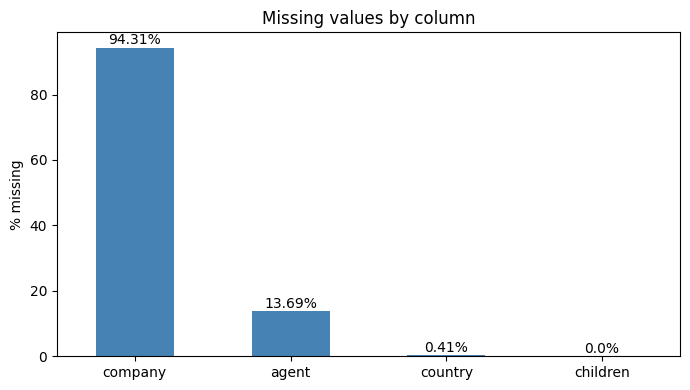

In [7]:

ax = missing_pct.plot(kind="bar", color="steelblue", figsize=(7, 4))
ax.set_ylabel("% missing")
ax.set_title("Missing values by column")
for i, v in enumerate(missing_pct):
    ax.text(i, v + 1, f"{v}%", ha="center")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# %% 3. Turn nulls into facts: was an agent / company involved?
df["has_agent"] = df["agent"].notnull().astype(int)
df["has_company"] = df["company"].notnull().astype(int)


has_agent
has_agent
0    0.246634
1    0.390044
Name: is_canceled, dtype: float64

has_company
has_company
0    0.382200
1    0.175224
Name: is_canceled, dtype: float64


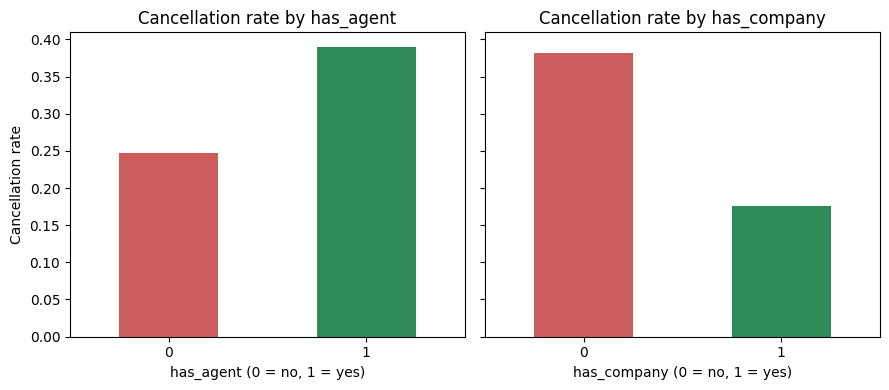

In [9]:
# %% 4. Test whether the nulls carry signal (cancellation rate per group)
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, col in zip(axes, ["has_agent", "has_company"]):
    rate = df.groupby(col)["is_canceled"].mean()
    print(f"\n{col}\n{rate}")
    rate.plot(kind="bar", ax=ax, color=["indianred", "seagreen"])
    ax.set_title(f"Cancellation rate by {col}")
    ax.set_xlabel(f"{col} (0 = no, 1 = yes)")
    ax.set_xticklabels([0, 1], rotation=0)
axes[0].set_ylabel("Cancellation rate")
plt.tight_layout()
plt.show()

In [10]:
# %% 5. Clean
df_clean = df.copy()
# Leaky columns: outcome of the booking, not known at booking time
df_clean = df_clean.drop(columns=["reservation_status", "reservation_status_date"])
# Raw IDs: too sparse / high-cardinality for now (flags already capture the signal)
df_clean = df_clean.drop(columns=["company", "agent"])

In [11]:
# Tiny gaps
df_clean["children"] = df_clean["children"].fillna(0)
df_clean["country"] = df_clean["country"].fillna("Unknown")
 
print(df_clean.isnull().sum().sum(), "missing values left")
print(df_clean.shape)

0 missing values left
(119390, 30)


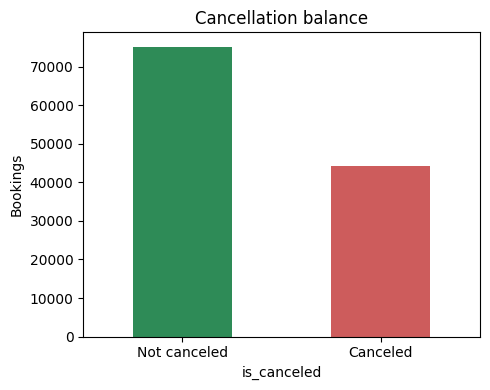

In [12]:

# %% 6. EDA plots
# 6a. Overall cancellation split
df_clean["is_canceled"].value_counts().rename({0: "Not canceled", 1: "Canceled"}).plot(
    kind="bar", color=["seagreen", "indianred"], figsize=(5, 4)
)
plt.title("Cancellation balance")
plt.ylabel("Bookings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

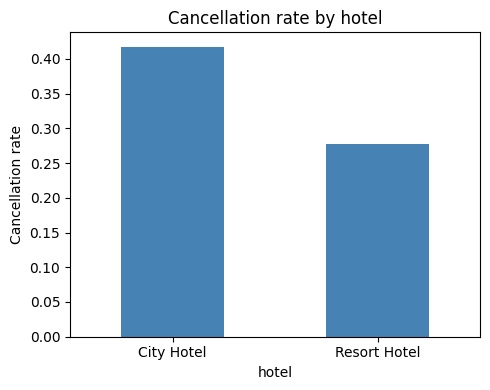

In [13]:
# 6b. Cancellation rate by hotel type
df_clean.groupby("hotel")["is_canceled"].mean().plot(
    kind="bar", color="steelblue", figsize=(5, 4)
)
plt.title("Cancellation rate by hotel")
plt.ylabel("Cancellation rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

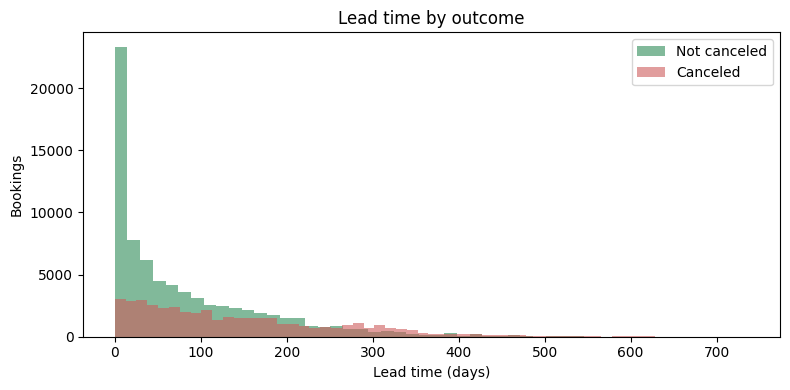

In [14]:
# 6c. Lead time: canceled vs not canceled
plt.figure(figsize=(8, 4))
plt.hist(df_clean.loc[df_clean["is_canceled"] == 0, "lead_time"],
        bins=50, alpha=0.6, label="Not canceled", color="seagreen")
plt.hist(df_clean.loc[df_clean["is_canceled"] == 1, "lead_time"],
        bins=50, alpha=0.6, label="Canceled", color="indianred")
plt.xlabel("Lead time (days)")
plt.ylabel("Bookings")
plt.title("Lead time by outcome")
plt.legend()
plt.tight_layout()
plt.show()

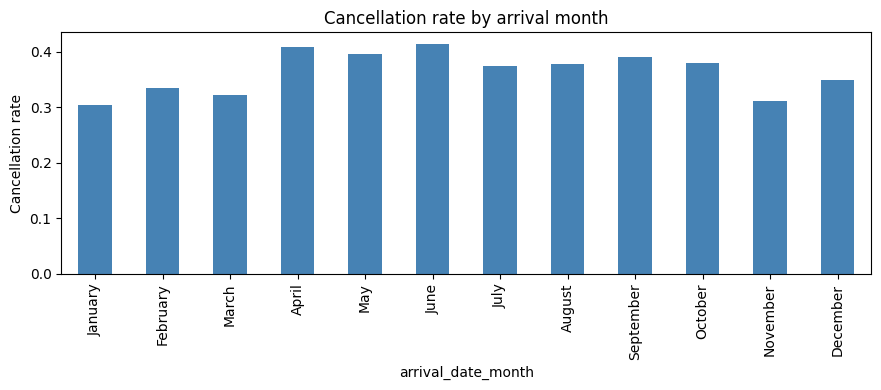

In [15]:
# 6d. Cancellation rate by arrival month
months = ["January", "February", "March", "April", "May", "June", "July",
    "August", "September", "October", "November", "December"]
(df_clean.groupby("arrival_date_month")["is_canceled"].mean()
    .reindex(months)
    .plot(kind="bar", color="steelblue", figsize=(9, 4)))
plt.title("Cancellation rate by arrival month")
plt.ylabel("Cancellation rate")
plt.tight_layout()
plt.show()

In [16]:
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, classification_report, roc_auc_score)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
RANDOM_STATE = 42

In [17]:
# %% 1. Load and clean
df = pd.read_csv("hotel_bookings.csv")
# Nulls carry meaning: was an agent / company involved?
df["has_agent"] = df["agent"].notnull().astype(int)
df["has_company"] = df["company"].notnull().astype(int)
# Drop leaky columns (outcome of the booking) and raw IDs
df = df.drop(columns=["reservation_status", "reservation_status_date",
            "agent", "company"])
# Drop columns only known AFTER booking (would leak in real use)
df = df.drop(columns=["assigned_room_type", "booking_changes"])

In [18]:
# Fill tiny gaps and remove price outliers
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df = df[df["adr"].between(0, 1000)]
X = df.drop(columns=["is_canceled"])
y = df["is_canceled"]
print("Data:", X.shape, "| cancellation rate:", round(y.mean(), 3))

Data: (119388, 27) | cancellation rate: 0.37


In [19]:
# %% 2. Split (stratified, before any fitting)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

In [20]:
def make_preprocessor():
    # Categories first, numbers after (HistGradientBoosting relies on this order)
    return ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                        unknown_value=-1), cat_cols),
        ("num", "passthrough", num_cols),
    ])

In [21]:

# %% 3. Candidate models + hyperparameter search (scored on ACCURACY)
cat_mask = [True] * len(cat_cols) + [False] * len(num_cols)
candidates = {
    "Gradient Boosting": (
        Pipeline([("prep", make_preprocessor()),
                ("clf", HistGradientBoostingClassifier(
                    categorical_features=cat_mask,
                    random_state=RANDOM_STATE))]),
        {
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__max_iter": [200, 400, 600],
            "clf__max_leaf_nodes": [31, 63, 127],
            "clf__min_samples_leaf": [20, 50, 100],
            "clf__l2_regularization": [0.0, 0.1, 1.0],
        },
        20,
    ),
    "Random Forest": (
        Pipeline([("prep", make_preprocessor()),
                ("clf", RandomForestClassifier(random_state=RANDOM_STATE))]),
        {
            "clf__n_estimators": [200, 400],
            "clf__max_depth": [None, 20, 30],
            "clf__min_samples_leaf": [1, 2, 4],
            "clf__max_features": ["sqrt", 0.3],
        },
        8,
    ),
}

In [22]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
searches = {}
for name, (pipe, params, n_iter) in candidates.items():
    print(f"\nTuning {name} ...")
    search = RandomizedSearchCV(pipe, params, n_iter=n_iter, cv=cv,
                                scoring="accuracy", n_jobs=-1,
                                random_state=RANDOM_STATE, verbose=1)
    search.fit(X_train, y_train)
    searches[name] = search
    print(f"{name}: best CV accuracy = {search.best_score_:.4f}")
    print("Best params:", search.best_params_)
best_name = max(searches, key=lambda n: searches[n].best_score_)
best_model = searches[best_name].best_estimator_
print(f"\nWinner (by CV accuracy): {best_name}")


Tuning Gradient Boosting ...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Gradient Boosting: best CV accuracy = 0.8740
Best params: {'clf__min_samples_leaf': 20, 'clf__max_leaf_nodes': 127, 'clf__max_iter': 600, 'clf__learning_rate': 0.05, 'clf__l2_regularization': 0.0}

Tuning Random Forest ...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/home/muhammad-shaheer/.venvs/jupyter-env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest: best CV accuracy = 0.8792
Best params: {'clf__n_estimators': 400, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.3, 'clf__max_depth': 30}

Winner (by CV accuracy): Random Forest



TEST accuracy: 0.8885
TEST ROC-AUC : 0.9555

              precision    recall  f1-score   support

Not canceled       0.90      0.93      0.91     15033
    Canceled       0.87      0.82      0.84      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.87      0.88     23878
weighted avg       0.89      0.89      0.89     23878



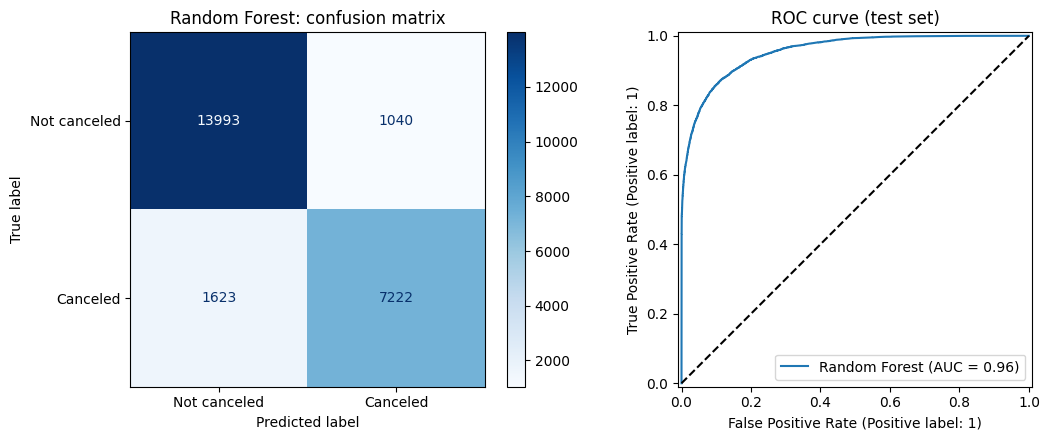

In [23]:

# %% 4. Final evaluation on the untouched test set
proba = best_model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print(f"\nTEST accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"TEST ROC-AUC : {roc_auc_score(y_test, proba):.4f}\n")
print(classification_report(y_test, pred,
                            target_names=["Not canceled", "Canceled"]))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["Not canceled", "Canceled"],
    cmap="Blues", ax=axes[0])
axes[0].set_title(f"{best_name}: confusion matrix")
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1], name=best_name)
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("ROC curve (test set)")
plt.tight_layout()
plt.show()

In [24]:
# %% 5. Save the whole pipeline (preprocessing + model) for later use
joblib.dump({"model": best_model, "columns": X.columns.tolist()},
            "cancellation_model.joblib")
print("Saved cancellation_model.joblib")

Saved cancellation_model.joblib
